# 🧠 Deep Learning Training Pipeline — CIC-IDS-2018
## Complete Fixed Pipeline + Correlation Feature Reduction

| Fix | Description |
|-----|-------------|
| ✅ Corrupt rows removed | Negative values from CICFlowMeter bug |
| ✅ Correct scaling order | Split → fit on train only → transform both (no leakage) |
| ✅ Honest metrics | Balanced Accuracy + per-class Recall (primary metrics) |
| ✅ Correlation feature drop | 57 → 34 features (23 redundant removed) |
| ✅ Native Keras format | Models saved as `.keras` (no legacy HDF5 warnings) |

**Models:** 1D-CNN · LSTM

**Features dropped (23):** Subflow Fwd Pkts, Fwd Seg Size Avg, Bwd Seg Size Avg, Subflow Fwd Byts, Subflow Bwd Pkts, TotLen Bwd Pkts, ECE Flag Cnt, Tot Fwd Pkts, Bwd Header Len, Idle Min, Fwd IAT Tot, Idle Mean, Subflow Bwd Byts, Pkt Len Mean, Flow IAT Min, Fwd Header Len, Fwd IAT Max, Flow IAT Mean, Fwd IAT Min, Bwd Pkt Len Std, Pkt Len Std, Fwd Pkt Len Std, Bwd Pkt Len Max

> Duplicate removal and class balancing are intentionally NOT applied here.
> Each optimisation is studied independently as per the research methodology.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
import os
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, BatchNormalization,
    Dropout, Dense, Flatten, LSTM,
    Reshape
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    balanced_accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns

print('=' * 80)
print('🧠 DEEP LEARNING TRAINING — CIC-IDS-2018 | FIXED PIPELINE + CORR DROP')
print('=' * 80)
print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'GPU devices: {tf.config.list_physical_devices("GPU")}')


🧠 DEEP LEARNING TRAINING — CIC-IDS-2018 | FIXED PIPELINE + CORR DROP
TensorFlow : 2.20.0
Keras      : 3.13.0
GPU devices: []


## 2. Configuration

In [2]:
INPUT_FILE       = 'archive/full_df_binary_labels.csv'
BASE_MODEL_DIR   = 'trained_models/dl_corr_drop/'
TEST_SIZE        = 0.2
VALIDATION_SPLIT = 0.2
RANDOM_STATE     = 42
SAVE_MODELS      = True

# Training hyperparameters
EPOCHS     = 20
BATCH_SIZE = 256
PATIENCE   = 10

# Per-model sample sizes (same as original DL notebook)
MODEL_SAMPLE_SIZES = {
    'CNN': 10000000,          # Use full dataset
    'LSTM': 200000,       # LSTM is slow, use 200k rows
}

# ── Features dropped by correlation analysis (23 features) ──────────────
CORRELATION_DROP = [
    'Subflow Fwd Pkts', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
    'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'TotLen Bwd Pkts',
    'ECE Flag Cnt', 'Tot Fwd Pkts', 'Bwd Header Len', 'Idle Min',
    'Fwd IAT Tot', 'Idle Mean', 'Subflow Bwd Byts', 'Pkt Len Mean',
    'Flow IAT Min', 'Fwd Header Len', 'Fwd IAT Max', 'Flow IAT Mean',
    'Fwd IAT Min', 'Bwd Pkt Len Std', 'Pkt Len Std', 'Fwd Pkt Len Std',
    'Bwd Pkt Len Max'
]

# ── Physically impossible negatives ──────────────────────────────────────
NON_NEGATIVE_FEATURES = [
    'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std',
    'Flow IAT Max',  'Flow IAT Min',  'Fwd IAT Tot',
    'Fwd IAT Mean',  'Fwd IAT Std',   'Fwd IAT Max',
    'Fwd IAT Min',   'Bwd IAT Tot',   'Bwd IAT Mean',
    'Bwd IAT Std',   'Bwd IAT Max',   'Bwd IAT Min',
    'Idle Mean',     'Idle Max',      'Idle Min',
    'Tot Fwd Pkts',  'Tot Bwd Pkts',  'TotLen Fwd Pkts',
    'TotLen Bwd Pkts', 'Flow Byts/s', 'Flow Pkts/s'
]

# ── Scaling groups — updated for 34 surviving features ───────────────────
POWER_TRANSFORMER_FEATURES = [
    'Dst Port', 'Flow Duration',
    'TotLen Fwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Mean',
    'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s',
    'Flow IAT Std', 'Flow IAT Max',
    'Fwd IAT Mean', 'Fwd IAT Std',
    'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min',
    'Fwd Pkts/s', 'Bwd Pkts/s',
    'Pkt Len Max', 'Pkt Len Var', 'Down/Up Ratio',
    'Pkt Size Avg', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
    'Fwd Act Data Pkts', 'Idle Max',
    'Tot Bwd Pkts'
]
STANDARD_SCALER_FEATURES = ['Fwd Seg Size Min']
NO_SCALING_FEATURES = [
    'Protocol', 'RST Flag Cnt', 'PSH Flag Cnt',
    'ACK Flag Cnt', 'URG Flag Cnt'
]

os.makedirs(BASE_MODEL_DIR, exist_ok=True)
print('✅ Configuration set')
print(f'   Output directory  : {BASE_MODEL_DIR}')
print(f'   Epochs            : {EPOCHS}')
print(f'   Batch size        : {BATCH_SIZE}')
print(f'   EarlyStopping pat.: {PATIENCE}')
print(f'   Features dropped  : {len(CORRELATION_DROP)} (correlation analysis)')
print(f'   Features remaining: 34')


✅ Configuration set
   Output directory  : trained_models/dl_corr_drop/
   Epochs            : 20
   Batch size        : 256
   EarlyStopping pat.: 10
   Features dropped  : 23 (correlation analysis)
   Features remaining: 34


## 3. Load Dataset

In [3]:
CHUNK_SIZE = 100_000
chunks, total = [], 0

print(f'\n📂 Loading data from: {INPUT_FILE}')
print('⏳ Reading in chunks...\n')

for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    chunks.append(chunk)
    total += len(chunk)
    if (i + 1) % 20 == 0:
        print(f'   Chunk {i+1:>4}: {len(chunk):,} rows | Total: {total:,}')

df_full = pd.concat(chunks, ignore_index=True)
del chunks

df_full = df_full.drop(columns=['Label'], errors='ignore')

print(f'\n✅ Dataset loaded')
print(f'   Rows   : {len(df_full):,}')
print(f'   Columns: {len(df_full.columns)}')
print(f'\nRaw class distribution:')
print(df_full['Label_Binary'].value_counts())



📂 Loading data from: archive/full_df_binary_labels.csv
⏳ Reading in chunks...

   Chunk   20: 100,000 rows | Total: 2,000,000
   Chunk   40: 100,000 rows | Total: 4,000,000
   Chunk   60: 100,000 rows | Total: 6,000,000
   Chunk   80: 100,000 rows | Total: 8,000,000
   Chunk  100: 100,000 rows | Total: 10,000,000
   Chunk  120: 100,000 rows | Total: 12,000,000
   Chunk  140: 100,000 rows | Total: 14,000,000
   Chunk  160: 100,000 rows | Total: 16,000,000

✅ Dataset loaded
   Rows   : 16,232,943
   Columns: 58

Raw class distribution:
Label_Binary
0    13484708
1     2748235
Name: count, dtype: int64


## 4. Data Cleaning — Remove Corrupt Rows
CICFlowMeter has a known bug where timestamp overflows produce **negative** values in duration and inter-arrival time features. These rows are physically impossible and removed.

In [4]:
print('=' * 80)
print('🧹 REMOVING CORRUPT ROWS (impossible negatives)')
print('=' * 80)

before = len(df_full)
cols_check = [c for c in NON_NEGATIVE_FEATURES if c in df_full.columns]

print('\nNegative value counts per feature:')
found_any = False
for col in cols_check:
    n_bad = (df_full[col] < 0).sum()
    if n_bad > 0:
        print(f'  ⚠️  {col:<35} {n_bad:>8,} corrupt values')
        found_any = True
if not found_any:
    print('  ✅ No negative values found in any checked feature')

corrupt_mask = (df_full[cols_check] < 0).any(axis=1)
df_full      = df_full[~corrupt_mask].copy()

print(f'\n  Before : {before:>12,}')
print(f'  Removed: {before - len(df_full):>12,} corrupt rows')
print(f'  After  : {len(df_full):>12,}')


🧹 REMOVING CORRUPT ROWS (impossible negatives)

Negative value counts per feature:
  ⚠️  Flow Duration                             14 corrupt values
  ⚠️  Flow IAT Mean                             14 corrupt values
  ⚠️  Flow IAT Max                               3 corrupt values
  ⚠️  Flow IAT Min                              15 corrupt values
  ⚠️  Fwd IAT Tot                               14 corrupt values
  ⚠️  Fwd IAT Mean                              14 corrupt values
  ⚠️  Fwd IAT Max                                3 corrupt values
  ⚠️  Fwd IAT Min                               15 corrupt values
  ⚠️  Flow Pkts/s                               14 corrupt values

  Before :   16,232,943
  Removed:           15 corrupt rows
  After  :   16,232,928


## 5. Prepare Features + Apply Correlation Drop
Drop the 23 features identified as redundant by the full-dataset correlation analysis. For each correlated pair (|r| ≥ 0.95), the feature with **lower label-correlation** was dropped.

In [5]:
print('\n' + '=' * 80)
print('🔧 PREPARING FEATURES + APPLYING CORRELATION DROP')
print('=' * 80)

X_full = df_full.drop(['Label_Binary'], axis=1).select_dtypes(include=[np.number])
y_full = df_full['Label_Binary']
del df_full

# Step 1: Drop zero-variance features
constant_cols = [c for c in X_full.columns if X_full[c].std() < 1e-10]
if constant_cols:
    print(f'\n  Dropping {len(constant_cols)} zero-variance features:')
    for c in constant_cols: print(f'    - {c}')
    X_full = X_full.drop(columns=constant_cols)
else:
    print('\n  ✅ No zero-variance features')

# Step 2: Apply correlation drop
cols_to_drop = [c for c in CORRELATION_DROP if c in X_full.columns]
X_full = X_full.drop(columns=cols_to_drop)
print(f'\n  ✅ Correlation drop: removed {len(cols_to_drop)} features')
print(f'     {cols_to_drop}')

# Record number of features for model building
NUM_FEATURES = X_full.shape[1]

print(f'\n✅ X_full : {X_full.shape}')
print(f'✅ y_full : {y_full.shape}')
print(f'✅ NUM_FEATURES = {NUM_FEATURES}  (used for model input shape)')
print(f'\nClass distribution:')
vc = y_full.value_counts()
for k, v in vc.items():
    label = 'Benign' if k == 0 else 'Attack'
    print(f'  {label} ({k}): {v:>10,}  ({v/len(y_full)*100:.1f}%)')

print(f'\n📋 Surviving features ({NUM_FEATURES}):')
for i, f in enumerate(X_full.columns.tolist(), 1):
    print(f'  {i:2d}. {f}')



🔧 PREPARING FEATURES + APPLYING CORRELATION DROP

  ✅ No zero-variance features

  ✅ Correlation drop: removed 23 features
     ['Subflow Fwd Pkts', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'TotLen Bwd Pkts', 'ECE Flag Cnt', 'Tot Fwd Pkts', 'Bwd Header Len', 'Idle Min', 'Fwd IAT Tot', 'Idle Mean', 'Subflow Bwd Byts', 'Pkt Len Mean', 'Flow IAT Min', 'Fwd Header Len', 'Fwd IAT Max', 'Flow IAT Mean', 'Fwd IAT Min', 'Bwd Pkt Len Std', 'Pkt Len Std', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max']

✅ X_full : (16232928, 34)
✅ y_full : (16232928,)
✅ NUM_FEATURES = 34  (used for model input shape)

Class distribution:
  Benign (0): 13,484,693  (83.1%)
  Attack (1):  2,748,235  (16.9%)

📋 Surviving features (34):
   1. Dst Port
   2. Protocol
   3. Flow Duration
   4. Tot Bwd Pkts
   5. TotLen Fwd Pkts
   6. Fwd Pkt Len Max
   7. Fwd Pkt Len Mean
   8. Bwd Pkt Len Mean
   9. Flow Byts/s
  10. Flow Pkts/s
  11. Flow IAT Std
  12. Flow IAT Max
  13. Fwd IAT Mean
  1

## 6. Helper Function — Prepare Data Per Model

In [6]:
def get_model_data_for_dl(X_full, y_full, model_name, sample_size=None,
                           test_size=0.2, random_state=42):
    """
    Prepare train/test splits for DL models.
    CORRECT ORDER:
      1. Sample (optional, for memory/speed)
      2. Split train/test FIRST — test set isolated immediately
      3. Fit scalers on TRAIN only
      4. Transform both sets — no data leakage
    """
    X = X_full.copy()
    y = y_full.copy()

    # Optional sampling (stratified)
    if sample_size is not None and sample_size < len(X):
        print(f'   📊 Sampling {sample_size:,} rows (from {len(X):,})')
        X, _, y, _ = train_test_split(
            X, y, train_size=sample_size,
            random_state=random_state, stratify=y
        )
        print(f'   Sampled class dist: {y.value_counts().to_dict()}')
    else:
        print(f'   📊 Using full dataset: {len(X):,} rows')

    # STEP 1: Split FIRST
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    print(f'   Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')

    X_train = X_train.copy()
    X_test  = X_test.copy()

    # STEP 2: Fit on TRAIN only, transform both
    print('   🔧 Scaling (fit on train only — no leakage)...')
    scalers = {}

    power_cols = [
        c for c in POWER_TRANSFORMER_FEATURES
        if c in X_train.columns and X_train[c].std() > 1e-10
    ]
    if power_cols:
        pt = PowerTransformer(method='yeo-johnson', standardize=True)
        pt.fit(X_train[power_cols])
        X_train[power_cols] = pt.transform(X_train[power_cols])
        X_test[power_cols]  = pt.transform(X_test[power_cols])
        scalers['power'] = pt
        print(f'      PowerTransformer : {len(power_cols)} features')

    std_cols = [
        c for c in STANDARD_SCALER_FEATURES
        if c in X_train.columns and X_train[c].std() > 1e-10
    ]
    if std_cols:
        ss = StandardScaler()
        ss.fit(X_train[std_cols])
        X_train[std_cols] = ss.transform(X_train[std_cols])
        X_test[std_cols]  = ss.transform(X_test[std_cols])
        scalers['standard'] = ss
        print(f'      StandardScaler   : {len(std_cols)} features')

    no_scale = [c for c in NO_SCALING_FEATURES if c in X_train.columns]
    if no_scale:
        print(f'      Unscaled         : {len(no_scale)} binary/flag features')

    print('   ✅ Scaling complete')

    # Convert to numpy for Keras
    X_train = X_train.values.astype(np.float32)
    X_test  = X_test.values.astype(np.float32)
    y_train = y_train.values.astype(np.float32)
    y_test  = y_test.values.astype(np.float32)

    return X_train, X_test, y_train, y_test, scalers

print('✅ Helper function defined')


✅ Helper function defined


## 7. Model Architectures

### CNN — 1D Convolutional Neural Network
```
Input (34,) → Reshape (34, 1)
→ Conv1D(64,  k=3, relu) → BN → MaxPool(2) → Dropout(0.3)
→ Conv1D(128, k=3, relu) → BN → MaxPool(2) → Dropout(0.3)
→ Conv1D(256, k=3, relu) → BN → MaxPool(2) → Dropout(0.4)
→ Flatten → Dense(256, relu) → BN → Dropout(0.5)
→ Dense(128, relu) → Dropout(0.4) → Dense(1, sigmoid)
```

### LSTM — Long Short-Term Memory
```
Input (34,) → Reshape (34, 1)
→ LSTM(128, return_sequences=True) → Dropout(0.3) → BN
→ LSTM(64,  return_sequences=False) → Dropout(0.3) → BN
→ Dense(128, relu) → Dropout(0.4)
→ Dense(64,  relu) → Dropout(0.3) → Dense(1, sigmoid)
```

In [7]:
def build_cnn_model(input_shape):
    """1D CNN for network traffic classification."""
    model = Sequential([
        Reshape((input_shape[0], 1), input_shape=input_shape),

        # Conv Block 1
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Conv Block 2
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Conv Block 3
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.4),

        # Dense head
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model


def build_lstm_model(input_shape):
    """LSTM for network traffic classification."""
    model = Sequential([
        Reshape((input_shape[0], 1), input_shape=input_shape),

        # LSTM layers
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        BatchNormalization(),

        LSTM(64, return_sequences=False),
        Dropout(0.3),
        BatchNormalization(),

        # Dense head
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model


model_builders = {
    'CNN' : build_cnn_model,
    'LSTM': build_lstm_model
}

print(f'✅ Defined {len(model_builders)} DL models to train:')
for name in model_builders:
    s = MODEL_SAMPLE_SIZES.get(name)
    print(f'   - {name:<6}  sample={s:,} rows  input_shape=({NUM_FEATURES},)')


✅ Defined 2 DL models to train:
   - CNN     sample=10,000,000 rows  input_shape=(34,)
   - LSTM    sample=200,000 rows  input_shape=(34,)


## 8. Train All Models

In [8]:
results       = {}
histories     = {}
saved_scalers = {}

for model_name, model_builder in model_builders.items():
    print('\n' + '=' * 80)
    print(f'🚀 TRAINING: {model_name}')
    print('=' * 80)

    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower())
    os.makedirs(model_dir, exist_ok=True)
    print(f'📁 Model directory: {model_dir}')

    sample_size = MODEL_SAMPLE_SIZES.get(model_name, None)

    # ── Prepare data ──────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test, scalers = get_model_data_for_dl(
        X_full, y_full, model_name, sample_size, TEST_SIZE, RANDOM_STATE
    )
    saved_scalers[model_name] = scalers

    # ── Build model ───────────────────────────────────────────────────────
    print(f'\n🔨 Building {model_name} model (input: {NUM_FEATURES} features)...')
    model = model_builder((NUM_FEATURES,))
    print('\n📋 Model Architecture:')
    model.summary()

    # ── Callbacks ─────────────────────────────────────────────────────────
    best_model_path = os.path.join(model_dir, 'best_model.keras')
    cb_list = [
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=best_model_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]

    # ── Train ─────────────────────────────────────────────────────────────
    print(f'\n⏱️  Training...')
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        callbacks=cb_list,
        verbose=1
    )
    train_time = time.time() - start_time
    print(f'\n✅ Training completed in {train_time:.2f}s ({train_time/60:.2f} min)')

    # ── Evaluate ──────────────────────────────────────────────────────────
    print(f'\n🔮 Evaluating on test set...')
    start_eval = time.time()

    test_loss, test_acc, test_prec, test_rec = model.evaluate(
        X_test, y_test, batch_size=BATCH_SIZE, verbose=1
    )

    y_pred_proba = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred       = (y_pred_proba > 0.5).astype(int).flatten()
    pred_time    = time.time() - start_eval
    print(f'✅ Evaluation completed in {pred_time:.2f}s')

    # ── Metrics ───────────────────────────────────────────────────────────
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='binary', zero_division=0)
    f1_macro  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    cm        = confusion_matrix(y_test, y_pred)

    TN, FP, FN, TP = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
    benign_recall    = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    attack_recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    benign_precision = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    attack_precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    balanced_acc     = (benign_recall + attack_recall) / 2

    print(f'\n📊 RESULTS:')
    print(f'   Loss               : {test_loss:.4f}')
    print(f'   Balanced Accuracy  : {balanced_acc:.4f}  ← primary metric')
    print(f'   F1 Macro           : {f1_macro:.4f}')
    print(f'   Benign Recall      : {benign_recall:.4f}')
    print(f'   Attack Recall      : {attack_recall:.4f}')
    print(f'   Benign Precision   : {benign_precision:.4f}')
    print(f'   Attack Precision   : {attack_precision:.4f}')
    print(f'   Plain Accuracy     : {accuracy:.4f}  ⚠️  (for reference only)')

    print(f'\n🕐 TIME:')
    print(f'   Train: {train_time:.2f}s ({train_time/60:.2f} min)')
    print(f'   Eval : {pred_time:.2f}s')

    print(f'\n📈 DATASET INFO:')
    print(f'   Total samples  : {len(X_train)+len(X_test):,}')
    print(f'   Train samples  : {len(X_train):,}')
    print(f'   Test samples   : {len(X_test):,}')
    print(f'   Epochs trained : {len(history.history["loss"])}')

    print(f'\n🎯 Confusion Matrix:')
    print(cm)
    print(f'   TN={TN:,}  FP={FP:,}  FN={FN:,}  TP={TP:,}')

    print(f'\n📋 Classification Report:')
    print(classification_report(y_test, y_pred,
                                target_names=['Benign','Attack'], zero_division=0))

    # ── Store results ─────────────────────────────────────────────────────
    results[model_name] = {
        'balanced_accuracy': float(balanced_acc),
        'f1_macro'         : float(f1_macro),
        'benign_recall'    : float(benign_recall),
        'attack_recall'    : float(attack_recall),
        'benign_precision' : float(benign_precision),
        'attack_precision' : float(attack_precision),
        'accuracy'         : float(accuracy),
        'precision'        : float(precision),
        'recall'           : float(recall),
        'f1_score'         : float(f1),
        'loss'             : float(test_loss),
        'train_time'       : train_time,
        'pred_time'        : pred_time,
        'confusion_matrix' : cm,
        'sample_size'      : len(X_train) + len(X_test),
        'train_samples'    : len(X_train),
        'test_samples'     : len(X_test),
        'epochs_trained'   : len(history.history['loss']),
        'TN': int(TN), 'FP': int(FP), 'FN': int(FN), 'TP': int(TP)
    }
    histories[model_name] = history

    # ── Save ──────────────────────────────────────────────────────────────
    if SAVE_MODELS:
        # Native Keras format (no legacy HDF5 warnings)
        final_path = os.path.join(model_dir, 'final_model.keras')
        model.save(final_path)
        print(f'\n💾 Final model saved  : {final_path}')
        print(f'💾 Best model saved   : {best_model_path}')

        if scalers:
            scaler_path = os.path.join(model_dir, 'scalers.pkl')
            with open(scaler_path, 'wb') as f:
                pickle.dump(scalers, f)
            print(f'💾 Scalers saved      : {scaler_path}')

        history_path = os.path.join(model_dir, 'history.pkl')
        with open(history_path, 'wb') as f:
            pickle.dump(history.history, f)
        print(f'💾 History saved      : {history_path}')

        metadata = {
            'model_name'          : model_name,
            'num_features'        : NUM_FEATURES,
            'feature_names'       : list(X_full.columns),
            'correlation_dropped' : CORRELATION_DROP,
            'sample_size'         : sample_size,
            'train_samples'       : len(X_train),
            'test_samples'        : len(X_test),
            'epochs'              : EPOCHS,
            'epochs_trained'      : len(history.history['loss']),
            'batch_size'          : BATCH_SIZE,
            'train_time'          : train_time,
            'metrics': {
                'balanced_accuracy': float(balanced_acc),
                'f1_macro'         : float(f1_macro),
                'benign_recall'    : float(benign_recall),
                'attack_recall'    : float(attack_recall),
                'accuracy'         : float(accuracy),
                'loss'             : float(test_loss)
            },
            'pipeline_fixes': [
                'corrupt_rows_removed',
                'split_before_scale',
                'correlation_feature_drop_23_features'
            ]
        }
        meta_path = os.path.join(model_dir, 'metadata.pkl')
        with open(meta_path, 'wb') as f:
            pickle.dump(metadata, f)
        print(f'💾 Metadata saved     : {meta_path}')

print('\n' + '=' * 80)
print('✅ ALL MODELS TRAINED & TESTED!')
print('=' * 80)



🚀 TRAINING: CNN
📁 Model directory: trained_models/dl_corr_drop/cnn
   📊 Sampling 10,000,000 rows (from 16,232,928)
   Sampled class dist: {0: 8307000, 1: 1693000}
   Train: 8,000,000 rows | Test: 2,000,000 rows
   🔧 Scaling (fit on train only — no leakage)...
      PowerTransformer : 28 features
      StandardScaler   : 1 features
      Unscaled         : 5 binary/flag features
   ✅ Scaling complete

🔨 Building CNN model (input: 34 features)...

📋 Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 34, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 34, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 34, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 17, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 8, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,761 (1.61 MB)

 Trainable params: 420,353 (1.60 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 34, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 34, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 34, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 34, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,377 (521.00 KB)

 Trainable params: 132,993 (519.50 KB)

 Non-trainable params: 384 (1.50 KB)


⏱️  Training...
Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9044 - loss: 0.2496 - precision: 0.7690 - recall: 0.5876
Epoch 1: val_loss improved from None to 0.17661, saving model to trained_models/dl_corr_drop/lstm\best_model.keras

Epoch 1: finished saving model to trained_models/dl_corr_drop/lstm\best_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 93ms/step - accuracy: 0.9443 - loss: 0.1694 - precision: 0.8916 - recall: 0.7642 - val_accuracy: 0.9467 - val_loss: 0.1766 - val_precision: 0.7872 - val_recall: 0.9383 - learning_rate: 0.0010
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9762 - loss: 0.0995 - precision: 0.9602 - recall: 0.8968
Epoch 2: val_loss improved from 0.17661 to 0.08115, saving model to trained_models/dl_corr_drop/lstm\best_model.keras

Epoch 2: finished saving model to trained_models/dl_corr_drop/lstm\best_model.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 88ms/step - accuracy: 0.9784 - loss: 0.0919 - precision: 0.9658 - recall: 

## 9. Results Summary

In [9]:
summary_df = pd.DataFrame(results).T
metric_cols = [
    'balanced_accuracy', 'f1_macro',
    'benign_recall', 'attack_recall',
    'benign_precision', 'attack_precision',
    'accuracy', 'loss', 'train_time', 'epochs_trained', 'sample_size'
]
summary_df = summary_df[metric_cols].astype({
    c: float for c in metric_cols
})
summary_df = summary_df.sort_values('balanced_accuracy', ascending=False)

print('\n' + '=' * 80)
print('📊 FINAL RESULTS — HONEST METRICS (34 features after correlation drop)')
print('=' * 80)
print('\nRanked by Balanced Accuracy:')
print(summary_df[[
    'balanced_accuracy','f1_macro','benign_recall','attack_recall',
    'benign_precision','attack_precision','accuracy','loss','train_time'
]].to_string())

print('\n⚠️  Balanced Accuracy = (Benign Recall + Attack Recall) / 2')
print('    This is the primary metric — plain accuracy is misleading on imbalanced data.')
print('    Benign Recall  → how many legitimate flows correctly identified')
print('    Attack Recall  → how many attacks correctly detected')

summary_df.to_csv(os.path.join(BASE_MODEL_DIR, 'results_summary.csv'))
print(f'\n✅ Results saved → {BASE_MODEL_DIR}results_summary.csv')
summary_df



📊 FINAL RESULTS — HONEST METRICS (34 features after correlation drop)

Ranked by Balanced Accuracy:
      balanced_accuracy  f1_macro  benign_recall  attack_recall  benign_precision  attack_precision  accuracy      loss   train_time
CNN            0.970274  0.981580       0.999922       0.940626          0.988043          0.999592  0.989883  0.045261  7570.874246
LSTM           0.968759  0.979495       0.998947       0.938571          0.987622          0.994524  0.988725  0.050473   871.110612

⚠️  Balanced Accuracy = (Benign Recall + Attack Recall) / 2
    This is the primary metric — plain accuracy is misleading on imbalanced data.
    Benign Recall  → how many legitimate flows correctly identified
    Attack Recall  → how many attacks correctly detected

✅ Results saved → trained_models/dl_corr_drop/results_summary.csv


,balanced_accuracy,f1_macro,benign_recall,attack_recall,benign_precision,attack_precision,accuracy,loss,train_time,epochs_trained,sample_size
CNN,0.970274,0.981580,0.999922,0.940626,0.988043,0.999592,0.989883,0.045261,7570.874246,20.0,10000000.0
LSTM,0.968759,0.979495,0.998947,0.938571,0.987622,0.994524,0.988725,0.050473,871.110612,20.0,200000.0


## 10. Training History — Loss & Accuracy Curves


📊 Plotting training history...
✅ Saved → trained_models/dl_corr_drop/training_history.png


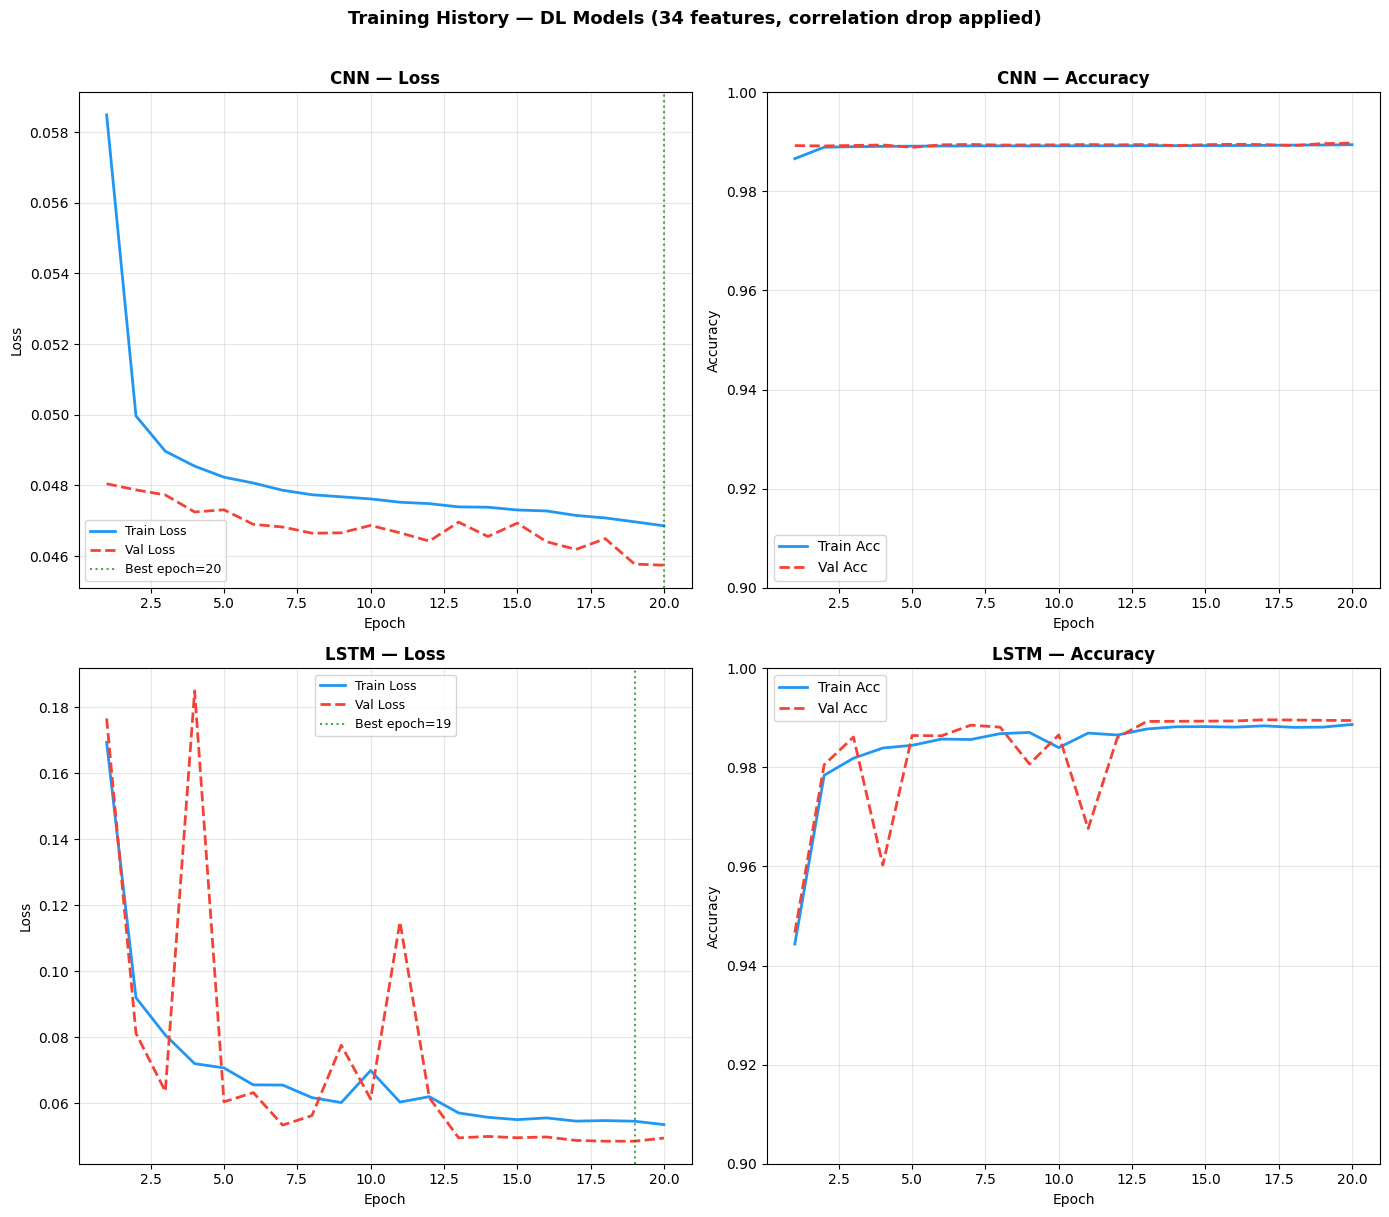

In [ ]:
print('\n📊 Plotting training history...')

n_models = len(histories)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 6 * n_models))
if n_models == 1:
    axes = axes.reshape(1, -1)

for idx, (model_name, history) in enumerate(histories.items()):
    h = history.history
    epochs_range = range(1, len(h['loss']) + 1)

    # Loss
    axes[idx, 0].plot(epochs_range, h['loss'],     label='Train Loss',
                      color='#2196F3', linewidth=2)
    axes[idx, 0].plot(epochs_range, h['val_loss'], label='Val Loss',
                      color='#F44336', linewidth=2, linestyle='--')
    axes[idx, 0].set_title(f'{model_name} — Loss', fontweight='bold', fontsize=12)
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].legend()
    axes[idx, 0].grid(alpha=0.3)
    # Mark best epoch
    best_ep = np.argmin(h['val_loss']) + 1
    axes[idx, 0].axvline(best_ep, color='green', linestyle=':', alpha=0.7,
                          label=f'Best epoch={best_ep}')
    axes[idx, 0].legend(fontsize=9)

    # Accuracy
    axes[idx, 1].plot(epochs_range, h['accuracy'],     label='Train Acc',
                      color='#2196F3', linewidth=2)
    axes[idx, 1].plot(epochs_range, h['val_accuracy'], label='Val Acc',
                      color='#F44336', linewidth=2, linestyle='--')
    axes[idx, 1].set_title(f'{model_name} — Accuracy', fontweight='bold', fontsize=12)
    axes[idx, 1].set_xlabel('Epoch')
    axes[idx, 1].set_ylabel('Accuracy')
    axes[idx, 1].legend()
    axes[idx, 1].grid(alpha=0.3)
    axes[idx, 1].set_ylim(0.9, 1.0)

plt.suptitle(
    'Training History — DL Models (34 features, correlation drop applied)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
hist_path = os.path.join(BASE_MODEL_DIR, 'training_history.png')
plt.savefig(hist_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {hist_path}')
plt.show()


## 11. Performance Comparison


📊 Creating performance comparison plots...
✅ Saved → trained_models/dl_corr_drop/model_comparison.png


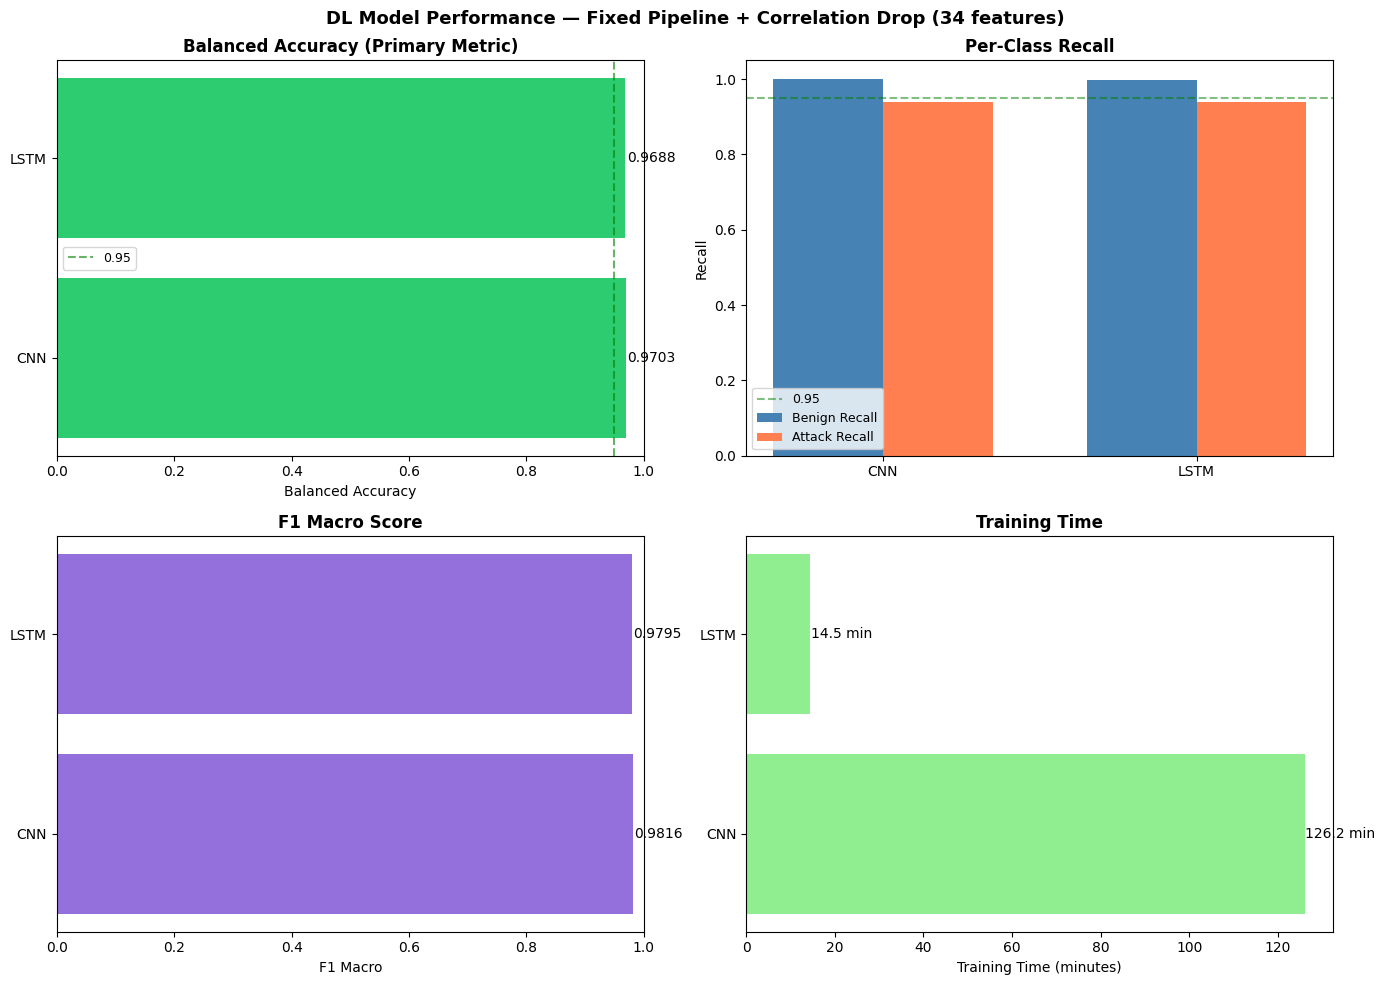

In [11]:
print('\n📊 Creating performance comparison plots...')

model_names = summary_df.index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'DL Model Performance — Fixed Pipeline + Correlation Drop (34 features)',
    fontsize=13, fontweight='bold'
)

# ── Balanced Accuracy ──
colors_ba = ['#2ecc71' if v >= 0.95 else '#f39c12' if v >= 0.90 else '#e74c3c'
             for v in summary_df['balanced_accuracy']]
axes[0,0].barh(model_names, summary_df['balanced_accuracy'], color=colors_ba)
axes[0,0].set_xlabel('Balanced Accuracy')
axes[0,0].set_title('Balanced Accuracy (Primary Metric)', fontweight='bold')
axes[0,0].set_xlim(0, 1)
axes[0,0].axvline(0.95, color='green', linestyle='--', alpha=0.6, label='0.95')
for i, v in enumerate(summary_df['balanced_accuracy']):
    axes[0,0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)
axes[0,0].legend(fontsize=9)

# ── Per-class Recall ──
x     = np.arange(len(model_names))
width = 0.35
axes[0,1].bar(x - width/2, summary_df['benign_recall'], width,
              label='Benign Recall', color='steelblue')
axes[0,1].bar(x + width/2, summary_df['attack_recall'], width,
              label='Attack Recall', color='coral')
axes[0,1].set_ylabel('Recall')
axes[0,1].set_title('Per-Class Recall', fontweight='bold')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(model_names, fontsize=10)
axes[0,1].set_ylim(0, 1.05)
axes[0,1].axhline(0.95, color='green', linestyle='--', alpha=0.5, label='0.95')
axes[0,1].legend(fontsize=9)

# ── F1 Macro ──
axes[1,0].barh(model_names, summary_df['f1_macro'], color='mediumpurple')
axes[1,0].set_xlabel('F1 Macro')
axes[1,0].set_title('F1 Macro Score', fontweight='bold')
axes[1,0].set_xlim(0, 1)
for i, v in enumerate(summary_df['f1_macro']):
    axes[1,0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

# ── Training Time ──
axes[1,1].barh(model_names, summary_df['train_time'] / 60, color='lightgreen')
axes[1,1].set_xlabel('Training Time (minutes)')
axes[1,1].set_title('Training Time', fontweight='bold')
for i, v in enumerate(summary_df['train_time'] / 60):
    axes[1,1].text(v + 0.05, i, f'{v:.1f} min', va='center', fontsize=10)

plt.tight_layout()
comp_path = os.path.join(BASE_MODEL_DIR, 'model_comparison.png')
plt.savefig(comp_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {comp_path}')
plt.show()


## 12. Confusion Matrices

✅ Saved → trained_models/dl_corr_drop/confusion_matrices.png


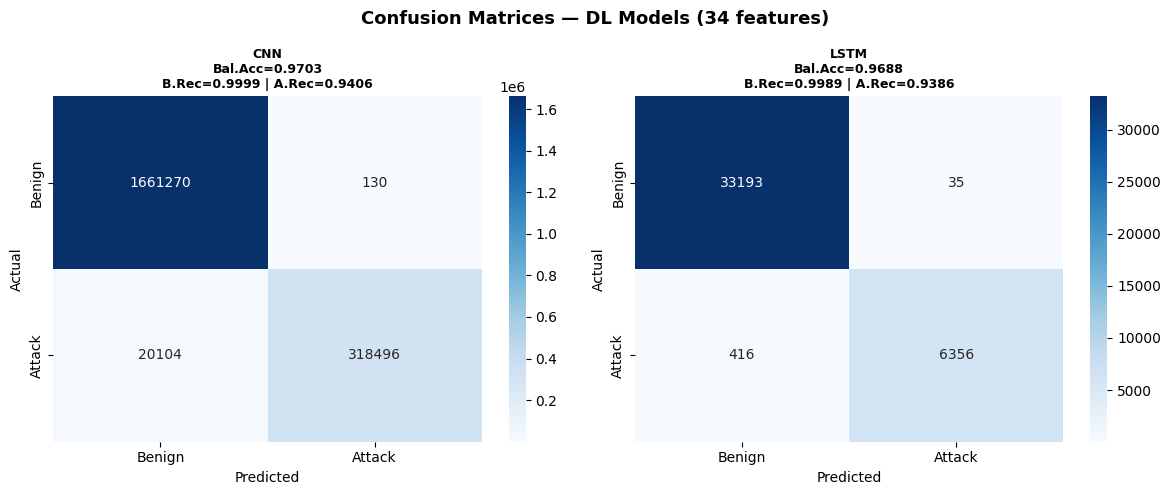

In [12]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for idx, model_name in enumerate(summary_df.index):
    r   = results[model_name]
    cm  = r['confusion_matrix']
    bal = r['balanced_accuracy']
    br  = r['benign_recall']
    ar  = r['attack_recall']

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
        xticklabels=['Benign', 'Attack'],
        yticklabels=['Benign', 'Attack']
    )
    axes[idx].set_title(
        f'{model_name}\nBal.Acc={bal:.4f}\n'
        f'B.Rec={br:.4f} | A.Rec={ar:.4f}',
        fontweight='bold', fontsize=9
    )
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle(
    'Confusion Matrices — DL Models (34 features)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
cm_path = os.path.join(BASE_MODEL_DIR, 'confusion_matrices.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {cm_path}')
plt.show()


## 13. Metrics Heatmap

✅ Saved → trained_models/dl_corr_drop/metrics_heatmap.png


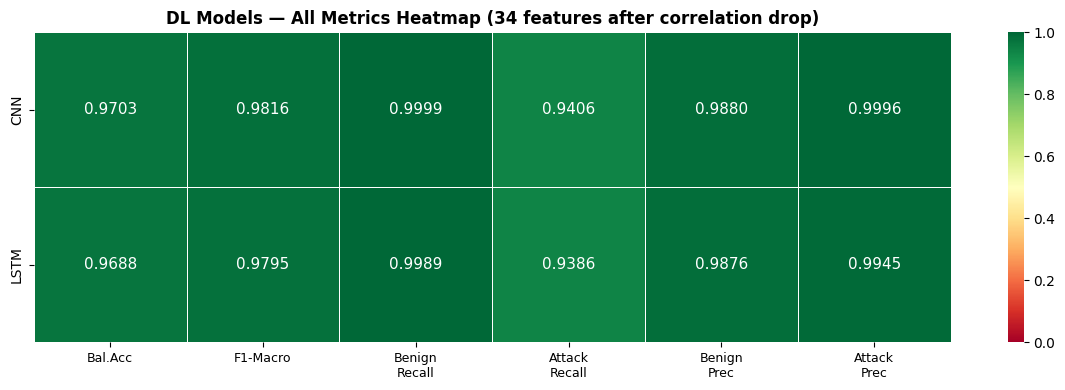

In [13]:
metric_cols_heat = [
    'balanced_accuracy', 'f1_macro',
    'benign_recall', 'attack_recall',
    'benign_precision', 'attack_precision'
]
metric_df = summary_df[metric_cols_heat].astype(float)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    metric_df, annot=True, fmt='.4f',
    cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 11}
)
ax.set_title(
    'DL Models — All Metrics Heatmap (34 features after correlation drop)',
    fontsize=12, fontweight='bold'
)
ax.set_xticklabels(
    ['Bal.Acc', 'F1-Macro', 'Benign\nRecall', 'Attack\nRecall',
     'Benign\nPrec', 'Attack\nPrec'],
    rotation=0, fontsize=9
)
plt.tight_layout()
heat_path = os.path.join(BASE_MODEL_DIR, 'metrics_heatmap.png')
plt.savefig(heat_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {heat_path}')
plt.show()


## 14. Final Summary

In [14]:
print('\n' + '=' * 80)
print('🎉 TRAINING COMPLETE — FIXED PIPELINE + CORRELATION DROP')
print('=' * 80)

print('\n📋 What was applied in this notebook:')
print('   ✅ Corrupt rows removed         (impossible negatives from CICFlowMeter bug)')
print('   ✅ Scaling done correctly        (split first → fit on train only — no leakage)')
print('   ✅ Honest metrics used           (Balanced Accuracy + per-class Recall)')
print('   ✅ Correlation feature drop      (57 → 34 features, 23 redundant removed)')
print('   ✅ Native Keras format           (no legacy HDF5 warnings)')

print('\n📊 Models Ranked by Balanced Accuracy:')
print(f'   {"Rank":<4} {"Model":<8} {"Bal.Acc":>8} '
      f'{"B.Recall":>9} {"A.Recall":>9} {"F1-Mac":>7} '
      f'{"Loss":>7} {"Epochs":>7} {"Time":>8}')
print('   ' + '─' * 72)
for rank, (model_name, row) in enumerate(summary_df.iterrows(), 1):
    t    = row['train_time']
    t_str = f'{t/60:.1f}min'
    print(f'   {rank:<4} {model_name:<8} '
          f'{row["balanced_accuracy"]:>8.4f} '
          f'{row["benign_recall"]:>9.4f} '
          f'{row["attack_recall"]:>9.4f} '
          f'{row["f1_macro"]:>7.4f} '
          f'{row["loss"]:>7.4f} '
          f'{int(row["epochs_trained"]):>7} '
          f'{t_str:>8}')

best = summary_df.index[0]
print(f'\n🏆 Best model: {best}')
print(f'   Balanced Accuracy : {summary_df.loc[best, "balanced_accuracy"]:.4f}')
print(f'   Benign Recall     : {summary_df.loc[best, "benign_recall"]:.4f}')
print(f'   Attack Recall     : {summary_df.loc[best, "attack_recall"]:.4f}')
print(f'\n📁 All models saved to: {BASE_MODEL_DIR}')
for model_name in model_builders:
    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower())
    print(f'   {model_dir}/')
    print(f'     best_model.keras  ← best val_loss checkpoint')
    print(f'     final_model.keras ← end-of-training weights')
    print(f'     scalers.pkl')
    print(f'     history.pkl')
    print(f'     metadata.pkl')

print('\n💡 Key reminder:')
print('   A good IDS needs HIGH recall on BOTH classes.')
print('   Low Benign Recall → too many false alarms (legitimate traffic blocked).')
print('   Low Attack Recall → attacks slipping through undetected.')
print(f'\n   Features used: {NUM_FEATURES} (down from 57 — 23 redundant dropped by correlation analysis)')
print("lower feature and better performace  this the last model will be implemented in  the final app  or chosen ml or dl likely ml xgbost")


🎉 TRAINING COMPLETE — FIXED PIPELINE + CORRELATION DROP

📋 What was applied in this notebook:
   ✅ Corrupt rows removed         (impossible negatives from CICFlowMeter bug)
   ✅ Scaling done correctly        (split first → fit on train only — no leakage)
   ✅ Honest metrics used           (Balanced Accuracy + per-class Recall)
   ✅ Correlation feature drop      (57 → 34 features, 23 redundant removed)
   ✅ Native Keras format           (no legacy HDF5 warnings)

📊 Models Ranked by Balanced Accuracy:
   Rank Model     Bal.Acc  B.Recall  A.Recall  F1-Mac    Loss  Epochs     Time
   ────────────────────────────────────────────────────────────────────────
   1    CNN        0.9703    0.9999    0.9406  0.9816  0.0453      20 126.2min
   2    LSTM       0.9688    0.9989    0.9386  0.9795  0.0505      20  14.5min

🏆 Best model: CNN
   Balanced Accuracy : 0.9703
   Benign Recall     : 0.9999
   Attack Recall     : 0.9406

📁 All models saved to: trained_models/dl_corr_drop/
   trained_models/d